# 06 — Alters-Kohorten & Spieler-Tabelle

**Frage:** Wo kommen die Rating-Zuwächse her? Treiben jüngere oder ältere Spieler*innen die Verbesserung?

1. Kohortenbildung nach Alter **in 2015** (erste Periode): <20, 20–30, 30–40, 40–50, >50
2. Pro Kohorte × Gruppe: Mean/Median der kumulativen Rating-Änderung
3. Heatmap Kohorte × Jahr
4. **Spieler-Tabelle** mit Name, aktueller ELO, Gesamt-Δ, Δ pro Jahr (2015–2025)

Filter: `active = TRUE AND analysis_group IS NOT NULL`.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
from _setup import load_query, apply_style, GROUP_PALETTE, GROUP_ORDER

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

apply_style()
pd.set_option('display.max_rows', 250)

## Datenbasis laden

In [2]:
sql = '''
SELECT
    gr.fide_id,
    p.name,
    p.analysis_group,
    p.std_rating AS current_rating,
    p.birth_year,
    EXTRACT(YEAR FROM gr.period)::int AS year,
    gr.rating_change_weighted
FROM game_results gr
JOIN players p ON p.fide_id = gr.fide_id
WHERE p.active = TRUE AND p.analysis_group IS NOT NULL
'''
df = load_query(sql)
df['rating_change_weighted'] = df['rating_change_weighted'].astype(float)
df['age_2015'] = 2015 - df['birth_year']

def age_bucket(a):
    if pd.isna(a): return 'unknown'
    if a < 20: return '<20'
    if a < 30: return '20-30'
    if a < 40: return '30-40'
    if a < 50: return '40-50'
    return '>50'
df['cohort'] = df['age_2015'].apply(age_bucket)
COHORT_ORDER = ['<20', '20-30', '30-40', '40-50', '>50']
print('Partien:', len(df), '| Spieler:', df['fide_id'].nunique())
df[['fide_id','name','analysis_group','birth_year','age_2015','cohort']].drop_duplicates('fide_id').head()

Partien: 153528 | Spieler: 278


,fide_id,name,analysis_group,birth_year,age_2015,cohort
0,24171760,"Shuvalova, Polina",female_top,2001,14,<20
1,121576,"Sosa, Tomas",male_control,1998,17,<20
3,105198,"Alonso, Salvador",male_control,1974,41,40-50
6,418811,"Merry, Alan B",male_control,1996,19,<20
7,107069,"Felgaer, Ruben",male_control,1981,34,30-40


## 1. Kohorten-Besetzung

Wie viele Spieler pro Kohorte × Gruppe?

In [3]:
players_meta = df[['fide_id','analysis_group','cohort']].drop_duplicates('fide_id')
cohort_counts = (
    players_meta.groupby(['analysis_group','cohort']).size()
    .unstack('cohort').reindex(columns=COHORT_ORDER, fill_value=0)
)
cohort_counts

cohort,<20,20-30,30-40,40-50,>50
analysis_group,,,,,
female_top,22.0,14.0,7.0,NaN,NaN
male_control,94.0,80.0,35.0,20.0,6.0


## 2. Kumulativer Rating-Gewinn pro Kohorte

Pro Spieler Σ `rating_change_weighted` über 2015–2025, dann Mean/Median je Kohorte × Gruppe.

In [4]:
total_per_player = (
    df.groupby(['analysis_group','cohort','fide_id'])['rating_change_weighted']
      .sum().reset_index(name='total_sum')
)
cohort_stats = total_per_player.groupby(['analysis_group','cohort']).agg(
    n_players=('fide_id','nunique'),
    mean_total=('total_sum','mean'),
    median_total=('total_sum','median'),
).round(1).reset_index()
cohort_stats.pivot(index='cohort', columns='analysis_group', values='mean_total').reindex(COHORT_ORDER)

analysis_group,female_top,male_control
cohort,,
<20,543.2,590.6
20-30,-22.8,-0.2
30-40,-77.0,-53.3
40-50,NaN,-67.2
>50,NaN,-58.6


/var/folders/3b/wd_8tgyj0x3d8fgs9v_jsn1m0000gn/T/ipykernel_6642/154143397.py:7: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(


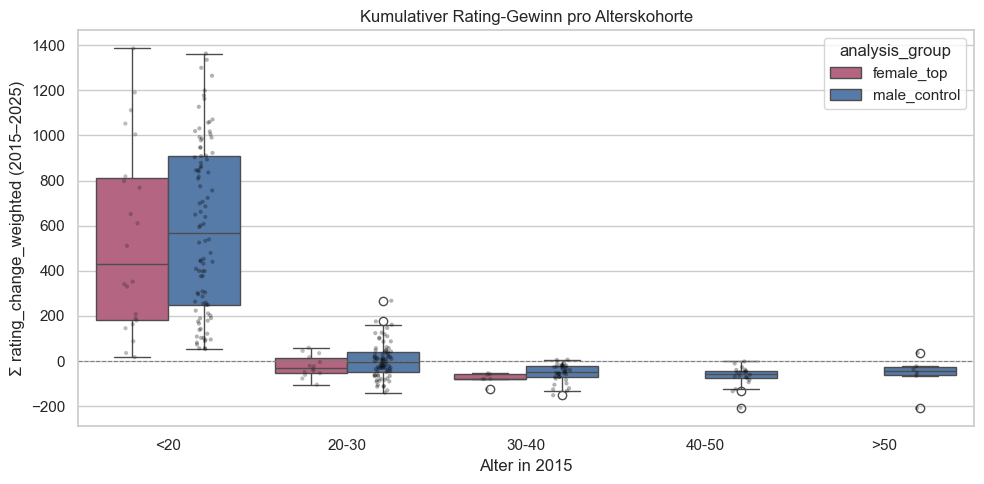

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=total_per_player, x='cohort', y='total_sum',
    hue='analysis_group', hue_order=GROUP_ORDER, palette=GROUP_PALETTE,
    order=COHORT_ORDER, ax=ax,
)
sns.stripplot(
    data=total_per_player, x='cohort', y='total_sum',
    hue='analysis_group', hue_order=GROUP_ORDER, dodge=True,
    order=COHORT_ORDER, color='black', alpha=0.3, size=3, ax=ax,
    legend=False,
)
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.set_ylabel('Σ rating_change_weighted (2015–2025)')
ax.set_xlabel('Alter in 2015')
ax.set_title('Kumulativer Rating-Gewinn pro Alterskohorte')
plt.tight_layout(); plt.show()

## 3. Heatmap Kohorte × Jahr

Mean Jahres-Summe pro Kohorte × Jahr, getrennt nach Gruppe. Zeigt, ob Gewinne gleichmäßig verteilt sind oder einzelne Jahre/Kohorten dominieren.

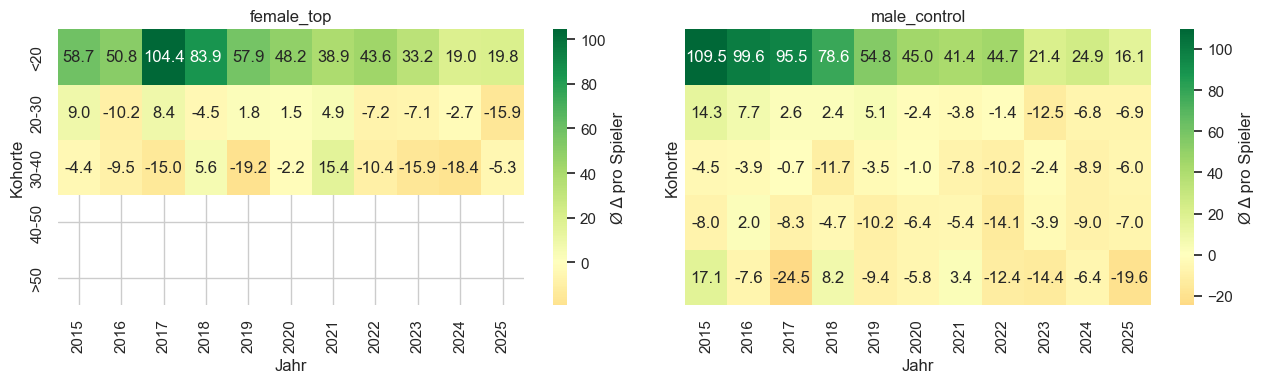

In [6]:
yearly_per_player = (
    df.groupby(['analysis_group','cohort','fide_id','year'])['rating_change_weighted']
      .sum().reset_index(name='yearly_sum')
)
yearly_cohort = (
    yearly_per_player.groupby(['analysis_group','cohort','year'])['yearly_sum']
                     .mean().round(1).reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, grp in zip(axes, GROUP_ORDER):
    sub = (yearly_cohort[yearly_cohort['analysis_group']==grp]
           .pivot(index='cohort', columns='year', values='yearly_sum')
           .reindex(COHORT_ORDER))
    sns.heatmap(sub, annot=True, fmt='.1f', cmap='RdYlGn', center=0, ax=ax,
                cbar_kws={'label':'Ø Δ pro Spieler'})
    ax.set_title(grp)
    ax.set_xlabel('Jahr'); ax.set_ylabel('Kohorte')
plt.tight_layout(); plt.show()

## 4. Spieler-Tabelle

Pro Spieler: aktueller ELO, Gesamt-Δ, Jahres-Δ 2015–2025. Sortiert alphabetisch.

In [7]:
yearly_wide = (
    yearly_per_player.pivot_table(
        index='fide_id', columns='year', values='yearly_sum', fill_value=0
    ).round(1)
)
yearly_wide.columns = [f'Δ {int(c)}' for c in yearly_wide.columns]

meta = df[['fide_id','name','analysis_group','current_rating','age_2015','cohort']].drop_duplicates('fide_id').set_index('fide_id')
totals = total_per_player.set_index('fide_id')['total_sum'].round(1).rename('Σ 2015–2025')

table = meta.join(totals).join(yearly_wide)
table = table.rename(columns={
    'name':'Name','analysis_group':'Gruppe',
    'current_rating':'ELO aktuell','age_2015':'Alter 2015','cohort':'Kohorte',
})
table = table.sort_values('Name').reset_index(drop=True)
print(f'{len(table)} Spieler')
table

278 Spieler


,Name,Gruppe,ELO aktuell,Alter 2015,Kohorte,Σ 2015–2025,Δ 2015,Δ 2016,Δ 2017,Δ 2018,Δ 2019,Δ 2020,Δ 2021,Δ 2022,Δ 2023,Δ 2024,Δ 2025
0,"Acosta, Pablo Ismael",male_control,2473,16,<20,190.2,30.6,81.0,-29.4,57.0,-38.0,49.1,7.7,-11.2,16.6,-24.3,51.1
1,"Adewumi, Tanitoluwa",male_control,2473,5,<20,698.8,0.0,0.0,0.0,0.0,0.0,0.0,405.6,177.2,-34.2,67.6,82.6
2,"Akhvlediani, Irakli",male_control,2429,15,<20,600.6,340.4,115.2,36.8,-54.6,38.0,37.2,74.2,6.6,-76.9,10.2,73.5
3,"Albornoz Cabrera, Carlos Daniel",male_control,2582,15,<20,304.1,65.8,110.6,37.1,66.0,-4.4,18.2,-6.4,11.2,21.2,-22.1,6.9
4,"Ali Marandi, Cemil Can",male_control,2514,17,<20,88.7,32.0,33.2,49.8,-9.3,7.4,5.3,-1.2,24.2,-27.5,-26.5,1.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
273,"Zanan, Evgeny",male_control,2497,17,<20,202.3,95.4,36.9,46.8,37.4,-28.5,27.5,7.1,-42.3,-2.4,-31.7,56.1
274,"Zhao, Xue",female_top,2433,30,30-40,-79.7,4.2,-14.6,-27.7,7.8,0.0,0.7,0.0,0.0,-36.0,-8.0,-6.1
275,"Zhu, Jiner",female_top,2554,13,<20,651.5,162.8,78.8,159.2,85.6,50.1,-1.8,18.3,8.2,-19.1,44.8,64.6
276,"Ziska, Helgi Dam",male_control,2542,25,20-30,24.7,20.7,22.1,-5.3,-6.4,-8.7,-1.0,5.6,3.4,4.5,-6.3,-3.9


### CSV-Export

In [8]:
out = Path('player_rating_changes.csv')
table.to_csv(out, index=False)
print(f'wrote {out}')

wrote player_rating_changes.csv
